In [1]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# For models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

True

In [2]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [3]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2807 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64
 16  End_Ad

## Frequency Encoding

In [4]:
# Frequency Encoding for Route
route_frequency = asr['Route_Standardized'].value_counts().to_dict()
asr['Route_Frequency'] = asr['Route_Standardized'].map(route_frequency)

print("Route Frequency Encoding Statistics:")
print(asr['Route_Frequency'].describe())
print(f"\nMost frequent route appears: {asr['Route_Frequency'].max()} times")
print(f"Least frequent routes appear: {asr['Route_Frequency'].min()} times")

# Show examples
print("\nSample of encoded routes:")
sample_df = asr[['Route', 'Route_Standardized', 'Route_Frequency']].drop_duplicates().sort_values('Route_Frequency', ascending=False).head(15)
print(sample_df)

Route Frequency Encoding Statistics:
count    2807.000000
mean        9.312789
std         8.412973
min         1.000000
25%         2.000000
50%         6.000000
75%        15.000000
max        35.000000
Name: Route_Frequency, dtype: float64

Most frequent route appears: 35 times
Least frequent routes appear: 1 times

Sample of encoded routes:
       Route Route_Standardized  Route_Frequency
29   LHR-JFK            LHR-JFK               35
119  LHR-JNB            LHR-JNB               32
45   JFK-LHR            JFK-LHR               29
91   LHR-DXB            LHR-DXB               26
126  LHR-CPT            LHR-CPT               26
511  LHR-BKK            LHR-BKK               25
51   LHR-HKG            LHR-HKG               24
559  LHR-MIA            LHR-MIA               23
21   YVR-LHR            YVR-LHR               23
949  BKK-LHR            BKK-LHR               23
117  LHR-YVR            LHR-YVR               22
81   JNB-LHR            JNB-LHR               22
55   HKG-LHR    

## Step 3: Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text (VADER compound score)
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Route_Frequency**: Frequency encoding of standardized routes (how popular is this route)

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Route popularity (frequency) and layover information capture route characteristics
- **Review-related**: Verified status and sentiment provide review quality indicators

### Route Feature Engineering:
- **Standardization**: Converted all "City1 to City2" formats to "City1-City2" for consistency
- **Frequency Encoding**: Popular routes get higher values, which may correlate with satisfaction
  - More frequent routes → Better established service
  - Less frequent routes → Potentially more issues or newer service


In [5]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type', 'Class', 'Verified', 'Sentiment_Score', 
    'Has_Layover'
]



print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Sentiment_Score  Has_Layover
count      2807.000000  2807.000000
mean          0.125478     0.172426
std           0.781512     0.377818
min          -0.997400     0.000000
25%          -0.765000     0.000000
50%           0.361200     0.000000
75%           0.918450     0.000000
max           0.999200     1.000000


In [6]:
# Prepare features (X) and target (y)
X = asr[feature_columns].copy()
y = asr['Satisfaction'].copy()

# Encode categorical variables
le_traveller = LabelEncoder()
le_class = LabelEncoder()
le_verified = LabelEncoder()

X['Traveller_Type'] = le_traveller.fit_transform(X['Traveller_Type'])
X['Class'] = le_class.fit_transform(X['Class'])
X['Verified'] = le_verified.fit_transform(X['Verified'])

print("Encoded feature mappings:")
print(f"Traveller_Type: {dict(zip(le_traveller.classes_, le_traveller.transform(le_traveller.classes_)))}")
print(f"Class: {dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))}")
print(f"Verified: {dict(zip(le_verified.classes_, le_verified.transform(le_verified.classes_)))}")
print(f"\nFinal dataset shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Encoded feature mappings:
Traveller_Type: {'Business': np.int64(0), 'Couple Leisure': np.int64(1), 'Family Leisure': np.int64(2), 'Solo Leisure': np.int64(3), 'Unknown': np.int64(4), 'Various': np.int64(5)}
Class: {'Business Class': np.int64(0), 'Economy Class': np.int64(1), 'First Class': np.int64(2), 'Premium Economy': np.int64(3), 'Unknown': np.int64(4)}
Verified: {'Not Verified': np.int64(0), 'Trip Verified': np.int64(1)}

Final dataset shape: (2807, 5)
Target distribution: {0: 1589, 1: 1218}


In [7]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2245
Test set size: 562

Training set target distribution:
Satisfaction
0    1271
1     974
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    318
1    244
Name: count, dtype: int64


### Model 1: Random Forest Classifierv

In [8]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8096
Precision: 0.7708
Recall:    0.7992
F1-Score:  0.7847

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.82      0.83       318
   Satisfied       0.77      0.80      0.78       244

    accuracy                           0.81       562
   macro avg       0.81      0.81      0.81       562
weighted avg       0.81      0.81      0.81       562



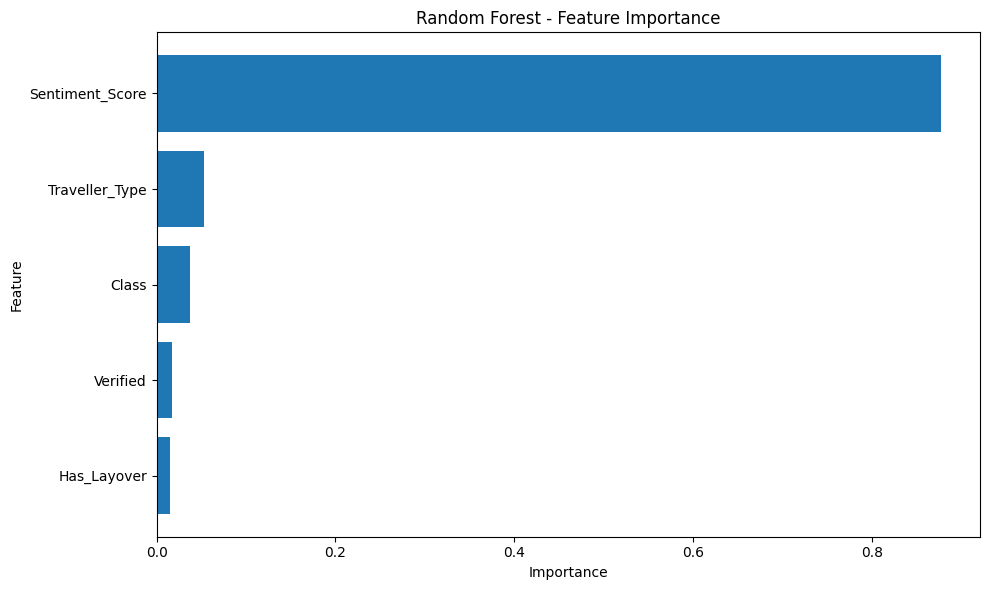


Feature Importance Rankings:
           feature  importance
3  Sentiment_Score    0.877384
0   Traveller_Type    0.052860
1            Class    0.037427
2         Verified    0.017055
4      Has_Layover    0.015274


In [10]:
# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance)

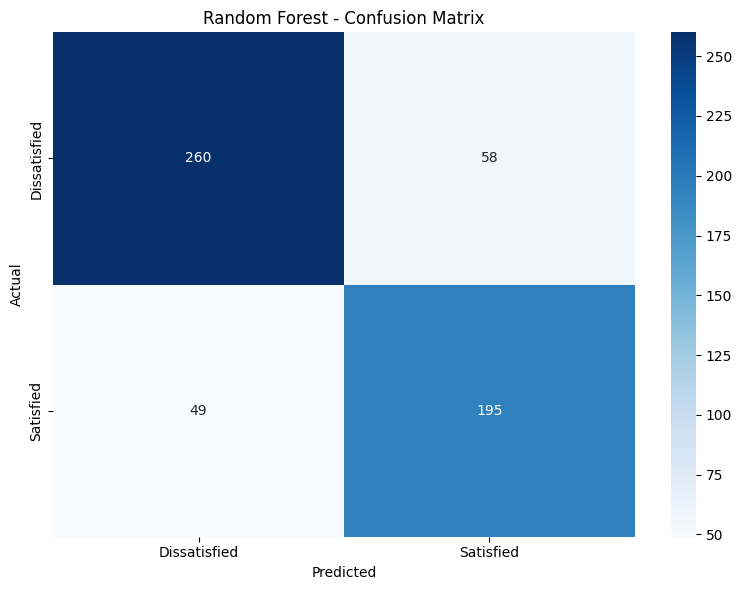

In [11]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [12]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2245, 5)
Test data shape: (562, 5)


In [13]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7222 - loss: 0.6250 - precision: 0.7216 - recall: 0.5592 - val_accuracy: 0.7840 - val_loss: 0.5519 - val_precision: 0.7468 - val_recall: 0.8271
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7845 - loss: 0.5387 - precision: 0.7223 - recall: 0.7974 - val_accuracy: 0.7929 - val_loss: 0.5282 - val_precision: 0.7510 - val_recall: 0.8458
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 0.5082 - precision: 0.7448 - recall: 0.8026 - val_accuracy: 0.7817 - val_loss: 0.5262 - val_precision: 0.7339 - val_recall: 0.8505
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7912 - loss: 0.5137 - precision: 0.7257 - recall: 0.8145 - val_accuracy: 0.7906 - val_loss: 0.5223 - val_precision: 0.7439 - val_recall: 0.8551
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7990 - loss: 0.5038 - precision: 0.7339 - recall: 0.8237 - val_accuracy: 0.7906 - val_loss: 0.5198 - val_preci

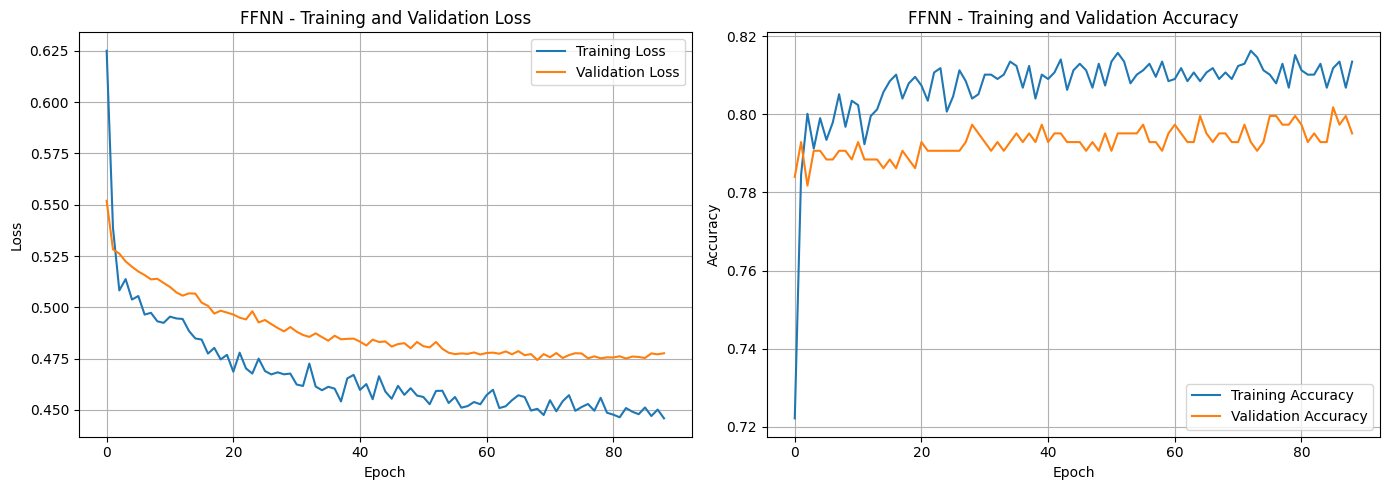

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
SHALLOW FFNN - RESULTS

Accuracy:  0.8060
Precision: 0.7586
Recall:    0.8115
F1-Score:  0.7842

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.85      0.80      0.82       318
   Satisfied       0.76      0.81      0.78       244

    accuracy                           0.81       562
   macro avg       0.80      0.81      0.80       562
weighted avg       0.81      0.81      0.81       562



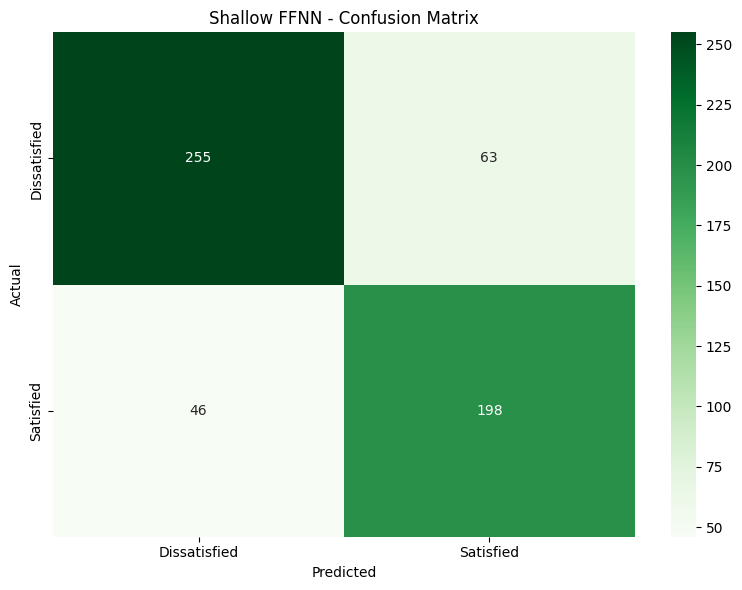

In [19]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.809609   0.770751 0.799180  0.784708
 Shallow FFNN  0.806050   0.758621 0.811475  0.784158


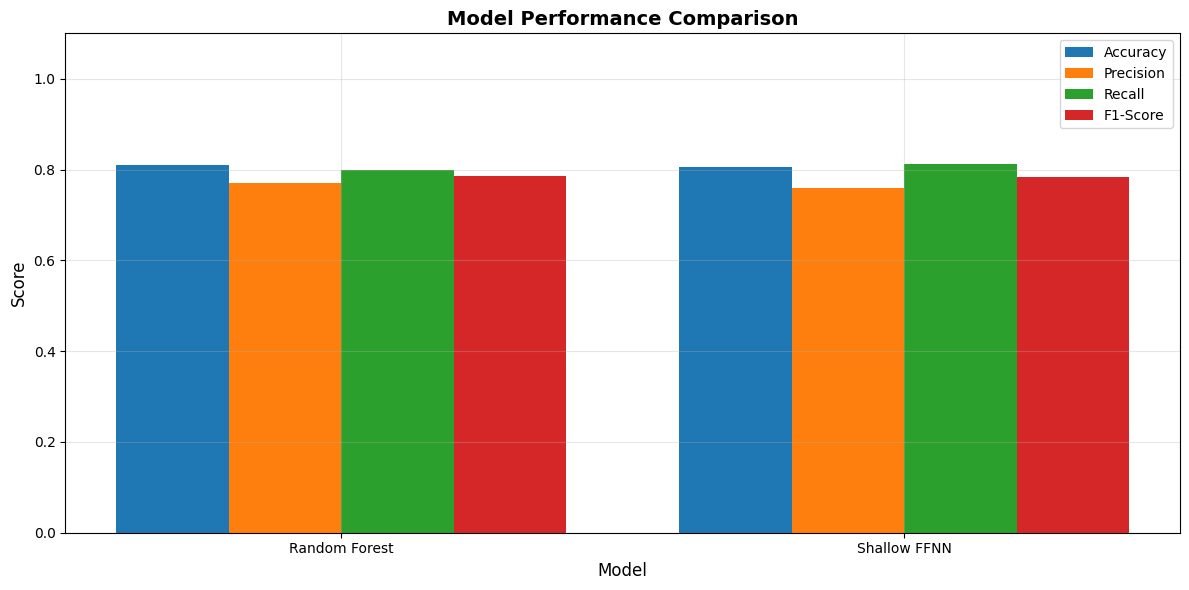

In [20]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Best practices combined
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Balance data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 2. Add powerful features
asr['Review_Length'] = asr['Review_content'].str.len()
asr['Sentiment_Strong'] = (asr['Sentiment_Score'].abs() > 0.5).astype(int)

# 3. Use XGBoost with class weights
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

xgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

XGBoost F1-Score: 0.7537


In [25]:
# Feature 1: Rating-based features (if available)
asr['Rating_Category'] = pd.cut(asr['Rating'], 
                                  bins=[0, 3, 7, 10], 
                                  labels=['Poor', 'Average', 'Excellent'])

# Feature 2: Review length (often correlates with sentiment intensity)
asr['Review_Length'] = asr['Review_content'].str.len()
asr['Review_Word_Count'] = asr['Review_content'].str.split().str.len()

# Feature 3: Sentiment intensity categories
asr['Sentiment_Category'] = pd.cut(asr['Sentiment_Score'],
                                     bins=[-1, -0.5, 0.5, 1],
                                     labels=['Negative', 'Neutral', 'Positive'])

# Feature 4: Route popularity tier
asr['Route_Popularity'] = pd.cut(asr['Route_Frequency'],
                                   bins=[0, 2, 5, 10, 100],
                                   labels=['Rare', 'Uncommon', 'Common', 'Popular'])

# Feature 5: Interaction features
asr['Class_Sentiment'] = asr['Class'] + '_' + asr['Sentiment_Category'].astype(str)
asr['Traveller_Class'] = asr['Traveller_Type'] + '_' + asr['Class']

# Feature 6: Sentiment-Rating alignment (strong predictor!)
asr['Sentiment_Rating_Match'] = ((asr['Sentiment_Score'] > 0) & (asr['Rating'] >= 5)) | \
                                  ((asr['Sentiment_Score'] < 0) & (asr['Rating'] < 5))

print("New features created!")
print(asr[['Review_Length', 'Review_Word_Count', 'Sentiment_Category', 
           'Route_Popularity', 'Sentiment_Rating_Match']].head())

New features created!
   Review_Length  Review_Word_Count Sentiment_Category Route_Popularity  \
0            700                136           Negative         Uncommon   
1           1804                320           Positive         Uncommon   
2            296                 53           Negative             Rare   
3            261                 48           Negative         Uncommon   
4           1025                182           Positive         Uncommon   

   Sentiment_Rating_Match  
0                    True  
1                   False  
2                    True  
3                    True  
4                    True  
